# Model Training

In this notebook, multiple machine learning classification models are trained and evaluated for customer churn prediction.

The saved preprocessing pipeline is reused to ensure consistent transformation of training and testing data.

The objective is to compare different algorithms and identify the best-performing model based on predictive performance and business requirements.

# Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Model persistence
import joblib

# Data splitting
from sklearn.model_selection import train_test_split

# Pipeline
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Load Preprocessing Pipeline

In [2]:
# Load processed features
preprocessor = joblib.load(
    "../models/preprocessor.pkl"
)

X_train = joblib.load(
    "../data/processed/X_train_processed.pkl"
)

X_test = joblib.load(
    "../data/processed/X_test_processed.pkl"
)


# Load target variables
y_train = joblib.load(
    "../data/processed/y_train.pkl"
)

y_test = joblib.load(
    "../data/processed/y_test.pkl"
)

# Verify Data

Check the dimensions of the processed datasets to confirm that preprocessing was successful.
Code

In [3]:
print("Training data:", X_train.shape)

print("Testing data:", X_test.shape)

Training data: (5634, 41)
Testing data: (1409, 41)


In [4]:
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


# Build Machine Learning Pipelines

Rather than preprocessing the data manually before training each model, a machine learning pipeline is created.

A pipeline combines:

1. Data preprocessing
2. Machine learning algorithm

into a single reusable workflow.

Benefits of using pipelines include:

- Preventing data leakage
- Ensuring consistent preprocessing
- Simplifying model evaluation
- Making hyperparameter tuning easier
- Producing a single deployable object

## Logistic Regression

Logistic Regression serves as the baseline model for customer churn prediction.

Although relatively simple, it performs well on many tabular datasets and produces probability estimates that are easy to interpret.

Class weighting is enabled to reduce the impact of class imbalance.

In [5]:
logistic_pipeline = Pipeline(
    steps=[
        ("classifier",
            LogisticRegression(
                C=1.0,
                penalty="l2",
                solver="lbfgs",
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

## Random Forest

Random Forest is an ensemble learning algorithm that combines predictions from many decision trees.

It captures nonlinear relationships and interactions between customer characteristics, often resulting in strong predictive performance on structured datasets.

In [6]:
rf_pipeline = Pipeline(
    steps=[
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=10,
                min_samples_split=10,
                min_samples_leaf=5,
                max_features="sqrt",
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

## Gradient Boosting

Gradient Boosting constructs decision trees sequentially.

Each new tree attempts to correct mistakes made by previous trees, allowing the model to learn increasingly complex decision boundaries.

Gradient Boosting is widely used for structured business datasets because of its strong predictive performance.


In [7]:
gb_pipeline = Pipeline(
    steps=[
        (
            "classifier",
            GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                min_samples_split=10,
                min_samples_leaf=5,
                subsample=0.8,
                random_state=42
            )
        )
    ]
)

# XGBoost Pipeline

XGBoost (Extreme Gradient Boosting) is one of the most powerful ensemble algorithms for structured (tabular) data.

It builds decision trees sequentially, where each new tree corrects the errors of the previous trees.

Advantages:
- Excellent predictive performance
- Handles complex feature interactions
- Robust to outliers
- Supports feature importance analysis

In [8]:
xgb_pipeline = Pipeline(
    steps=[
        ("classifier",
            XGBClassifier(
                random_state=42,
                eval_metric="logloss",
                n_estimators=300,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8
            ),
        ),
    ]
)

# LightGBM Pipeline

LightGBM is a gradient boosting framework developed by Microsoft.

Compared to XGBoost, LightGBM is generally:
- Faster to train
- More memory efficient
- Excellent for large datasets
- Highly accurate for tabular data

In [9]:
lgbm_pipeline = Pipeline(
    steps=[
        (
            "classifier",
            LGBMClassifier(
                random_state=42,
                n_estimators=300,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8
            ),
        ),
    ]
)

# Inspect Machine Learning Pipelines

Before training, inspect each pipeline to verify that the preprocessing step and classifier have been correctly combined.

Each pipeline should contain:

- The preprocessing pipeline
- The selected classification algorithm

In [10]:
# Logistic Regression Pipeline
logistic_pipeline

,steps,"[('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'


In [11]:
# Random Forest Pipeline
rf_pipeline

,steps,"[('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_estimators,300
,criterion,'gini'
,max_depth,10
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'


In [12]:
# Gradient Boosting Pipeline
gb_pipeline

,steps,"[('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,loss,'log_loss'
,learning_rate,0.05
,n_estimators,200
,subsample,0.8
,criterion,'friedman_mse'
,min_samples_split,10
,min_samples_leaf,5


In [13]:
# XGB classifier pipeline
xgb_pipeline

,steps,"[('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8


In [14]:
# lgbm classifier pipeline
lgbm_pipeline

,steps,"[('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None


# Train Machine Learning Models

Each machine learning pipeline is trained using the training dataset.

During training, the preprocessing pipeline automatically transforms the input features before passing them to the classifier.

Training multiple baseline models allows us to compare different learning algorithms and identify the strongest candidates for further optimization.

In [15]:
# Train Logistic Regression

logistic_pipeline.fit(
    X_train,
    y_train
)

print("Logistic Regression training complete.")

Logistic Regression training complete.


In [16]:
# Train Random Forest

rf_pipeline.fit(
    X_train,
    y_train
)

print("Random Forest training complete.")

Random Forest training complete.


In [17]:
# Train Gradient Boosting

gb_pipeline.fit(
    X_train,
    y_train
)

print("Gradient Boosting training complete.")

Gradient Boosting training complete.


In [18]:
# Train XGB classifier
xgb_pipeline.fit(
    X_train,
    y_train
)

print("XGBoost training complete.")

XGBoost training complete.


In [19]:
# Train LightGBM pipeline

lgbm_pipeline.fit(
    X_train,
    y_train
)

print("LightGBM training complete.")

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001442 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 418
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

# Generate Predictions

After training, each model is used to make predictions on the unseen testing dataset.

Two outputs are generated:

- Predicted class labels
- Predicted probabilities

The probability estimates are required for calculating ROC-AUC and plotting ROC curves.

In [20]:
# Logistic Regression Predictions

logistic_predictions = logistic_pipeline.predict(
    X_test
)

logistic_probabilities = logistic_pipeline.predict_proba(
    X_test
)[:, 1]

In [21]:
# Random Forest Predictions

rf_predictions = rf_pipeline.predict(
    X_test
)

rf_probabilities = rf_pipeline.predict_proba(
    X_test
)[:, 1]

In [22]:
# Gradient Boosting Predictions

gb_predictions = gb_pipeline.predict(
    X_test
)

gb_probabilities = gb_pipeline.predict_proba(
    X_test
)[:, 1]

In [23]:
# xgb Predictions

xgb_predictions = xgb_pipeline.predict(
    X_test
)

xgb_probabilities = xgb_pipeline.predict_proba(
    X_test
)[:, 1]

In [24]:
# lgbm Predictions

lgbm_predictions = lgbm_pipeline.predict(
    X_test
)

lgbm_probabilities = lgbm_pipeline.predict_proba(
    X_test
)[:, 1]

# Evaluate Model Performance

To ensure consistency across models, a reusable evaluation function is created.

The following performance metrics are calculated:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

For customer churn prediction, Recall and ROC-AUC are particularly important because identifying customers who are likely to churn enables proactive retention efforts.

In [25]:
def evaluate_model(model, X_test, y_test):
    
    # Generate predictions
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    # Calculate evaluation metrics
    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions
    )

    recall = recall_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions
    )
    
    roc_auc = roc_auc_score(
        y_test,
        probabilities
    )

    # Display evaluation metrics
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    print("\nClassification Report\n")

    print(
        classification_report(
            y_test,
            predictions
        )
    )

    # Return metrics
    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

# Model Evaluation

In [26]:
# Logistic Regression Performance

logistic_results = evaluate_model(

    logistic_pipeline,

    X_test,

    y_test
)

Accuracy : 0.7402
Precision: 0.5070
Recall   : 0.7754
F1 Score : 0.6131
ROC-AUC  : 0.8384

Classification Report

              precision    recall  f1-score   support

           0       0.90      0.73      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [27]:
# Random Forest Performance
rf_results = evaluate_model(

    rf_pipeline,

    X_test,

    y_test
)

Accuracy : 0.7559
Precision: 0.5283
Recall   : 0.7487
F1 Score : 0.6195
ROC-AUC  : 0.8377

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1035
           1       0.53      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409



In [28]:
# Gradient Boosting Performance
gb_results = evaluate_model(

    gb_pipeline,

    X_test,

    y_test
)

Accuracy : 0.7999
Precision: 0.6586
Recall   : 0.5107
F1 Score : 0.5753
ROC-AUC  : 0.8462

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [29]:
# XGB Performance
xgb_results = evaluate_model(

    xgb_pipeline,

    X_test,

    y_test
)

Accuracy : 0.7942
Precision: 0.6346
Recall   : 0.5294
F1 Score : 0.5773
ROC-AUC  : 0.8307

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.53      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



In [30]:
# lgbm Performance
lgbm_results = evaluate_model(

    lgbm_pipeline,

    X_test,

    y_test
)

Accuracy : 0.7913
Precision: 0.6333
Recall   : 0.5080
F1 Score : 0.5638
ROC-AUC  : 0.8335

Classification Report

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.51      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



# Compare Model Performance

The evaluation metrics from all trained models are consolidated into a single comparison table.

This provides an objective basis for identifying the strongest models before hyperparameter optimization.

Rather than relying solely on accuracy, multiple metrics are considered because different evaluation measures capture different aspects of model performance.

In [31]:
results_df = pd.DataFrame({

    "Model": [

        "Logistic Regression",

        "Random Forest",

        "Gradient Boosting", 
        
        "Xtreme Gradient Boosting", 
        
        "Light GBM"

    ],

     "Accuracy": [

        logistic_results["Accuracy"],

        rf_results["Accuracy"],

        gb_results["Accuracy"],

        xgb_results["Accuracy"],

        lgbm_results["Accuracy"]

    ],

    "Precision": [

        logistic_results["Precision"],

        rf_results["Precision"],

        gb_results["Precision"],

        xgb_results["Precision"],

        lgbm_results["Precision"]

    ],

    "Recall": [

        logistic_results["Recall"],

        rf_results["Recall"],

        gb_results["Recall"],

        xgb_results["Recall"],

        lgbm_results["Recall"]

    ],

    "F1 Score": [

        logistic_results["F1 Score"],

        rf_results["F1 Score"],

        gb_results["F1 Score"],

        xgb_results["F1 Score"],

        lgbm_results["F1 Score"]

    ],

    "ROC-AUC": [

        logistic_results["ROC-AUC"],

        rf_results["ROC-AUC"],

        gb_results["ROC-AUC"],

        xgb_results["ROC-AUC"],

        lgbm_results["ROC-AUC"]

    ]

})

results_df = results_df.round(4)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7402,0.5070,0.7754,0.6131,0.8384
1,Random Forest,0.7559,0.5283,0.7487,0.6195,0.8377
2,Gradient Boosting,0.7999,0.6586,0.5107,0.5753,0.8462
3,Xtreme Gradient Boosting,0.7942,0.6346,0.5294,0.5773,0.8307
4,Light GBM,0.7913,0.6333,0.5080,0.5638,0.8335


In [32]:
# Create a reusable function for plotting confusion matrices

def plot_confusion_matrix(model, X_test, y_test, title):

    predictions = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        predictions
    )

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(title)

    plt.xlabel("Predicted Label")

    plt.ylabel("Actual Label")

    plt.tight_layout()

    plt.show()

# Rank Models

The trained models are ranked according to business priorities.

For customer churn prediction:

1. **Recall** is prioritized because correctly identifying customers who are likely to churn enables proactive retention efforts.

2. **ROC-AUC** is considered next because it measures the model's ability to distinguish between churning and non-churning customers across different classification thresholds.

3. **F1-score** is used as a tie-breaker because it balances Precision and Recall, ensuring that the model maintains strong overall classification performance.

Models with higher values for these metrics are considered stronger candidates for further optimization.

In [33]:
# Rank models based on business priorities

ranked_models = results_df.sort_values(
    by=["Recall", "ROC-AUC", "F1 Score"],
    ascending=False
)

ranked_models

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7402,0.5070,0.7754,0.6131,0.8384
1,Random Forest,0.7559,0.5283,0.7487,0.6195,0.8377
3,Xtreme Gradient Boosting,0.7942,0.6346,0.5294,0.5773,0.8307
2,Gradient Boosting,0.7999,0.6586,0.5107,0.5753,0.8462
4,Light GBM,0.7913,0.6333,0.5080,0.5638,0.8335


In [34]:
# Select the top three models for optimization

top_models = ranked_models.head(3)

top_models

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7402,0.5070,0.7754,0.6131,0.8384
1,Random Forest,0.7559,0.5283,0.7487,0.6195,0.8377
3,Xtreme Gradient Boosting,0.7942,0.6346,0.5294,0.5773,0.8307


In [35]:
# Save model comparison results

ranked_models.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

In [36]:
# Names of the top three baseline models

top_model_names = top_models["Model"].tolist()

print("Top Models Selected for Optimization:")

for i, model in enumerate(top_model_names, start=1):
    print(f"{i}. {model}")

Top Models Selected for Optimization:
1. Logistic Regression
2. Random Forest
3. Xtreme Gradient Boosting


# Visual Model Evaluation for the top 3 performing models

Numerical evaluation metrics provide a quantitative assessment of model performance, while visualizations offer additional insight into how each model behaves.

In this section, the trained models are compared using:

- Confusion Matrices
- ROC Curves
- Precision-Recall Curves
- Performance Comparison Charts

These visualizations help identify strengths and weaknesses that may not be immediately apparent from summary metrics alone.

# Confusion Matrices

### A confusion matrix summarizes prediction outcomes by comparing the predicted class labels against the actual labels.

The matrix contains:

- True Positives (TP)
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)

For customer churn prediction, minimizing False Negatives is especially important because these represent customers who are predicted to stay but actually churn.

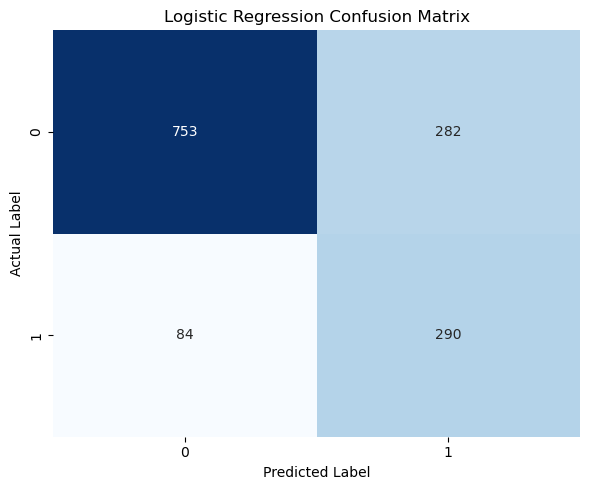

In [37]:
# Logistic Regression

plot_confusion_matrix(
    logistic_pipeline,
    X_test,
    y_test,
    "Logistic Regression Confusion Matrix"
)

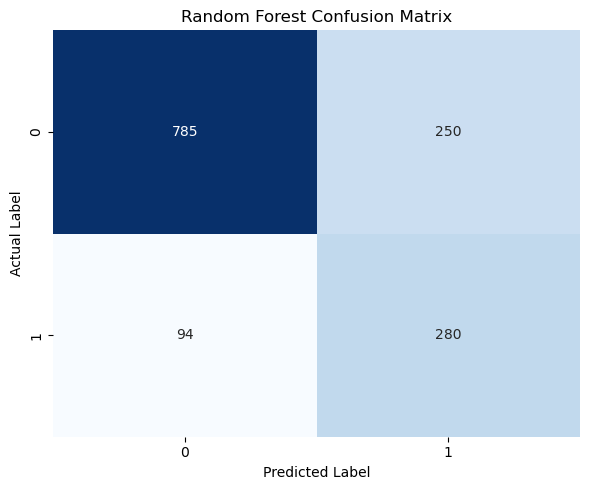

In [38]:
# Random Forest
plot_confusion_matrix(
    rf_pipeline,
    X_test,
    y_test,
    "Random Forest Confusion Matrix"
)

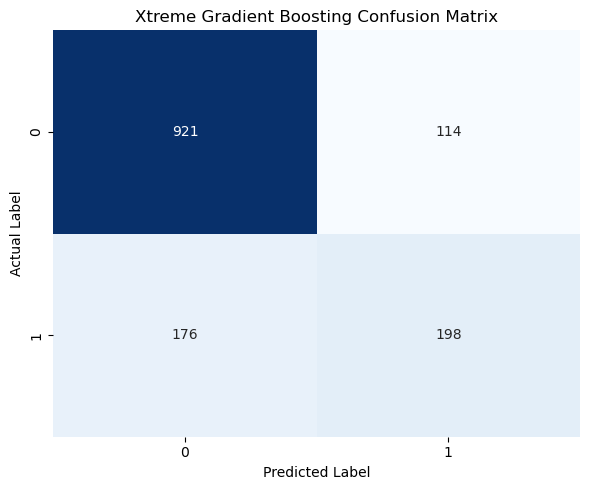

In [39]:
# Xtreme Gradient Boosting

plot_confusion_matrix(
    xgb_pipeline,
    X_test,
    y_test,
    "Xtreme Gradient Boosting Confusion Matrix"
)

# ROC Curve Comparison

The Receiver Operating Characteristic (ROC) curve illustrates a model's ability to distinguish between customers who churn and those who remain.

The Area Under the ROC Curve (ROC-AUC) summarizes this performance.

Higher ROC-AUC values indicate stronger classification capability.

<Figure size 800x600 with 0 Axes>

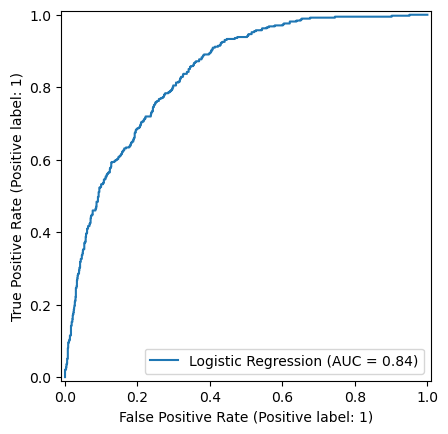

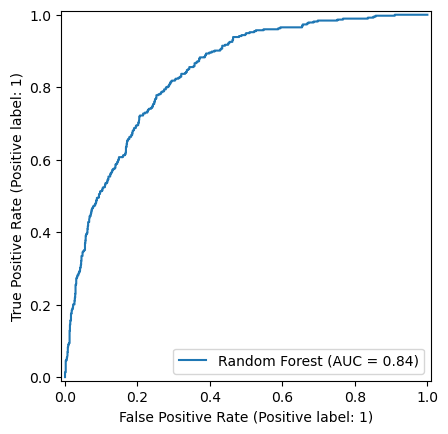

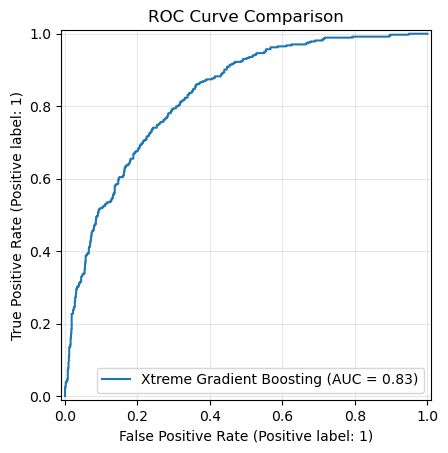

In [40]:
plt.figure(figsize=(8,6))

RocCurveDisplay.from_estimator(
    logistic_pipeline,
    X_test,
    y_test,
    name="Logistic Regression"
)

RocCurveDisplay.from_estimator(
    rf_pipeline,
    X_test,
    y_test,
    name="Random Forest"
)

RocCurveDisplay.from_estimator(
    xgb_pipeline,
    X_test,
    y_test,
    name="Xtreme Gradient Boosting"
)

plt.title("ROC Curve Comparison")

plt.grid(alpha=0.3)

plt.show()

# Precision-Recall Curve

The Precision-Recall Curve provides additional insight into model performance when dealing with imbalanced datasets.

Because customer churn datasets often contain fewer churning customers than retained customers, Precision-Recall curves can be more informative than ROC curves.

<Figure size 800x600 with 0 Axes>

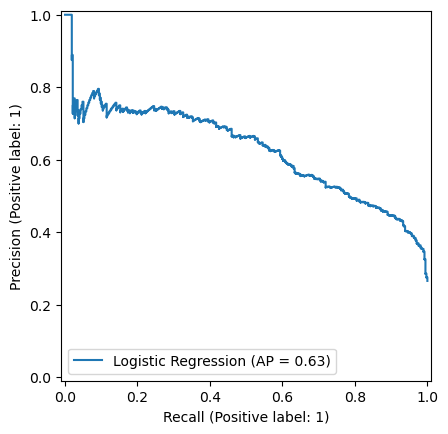

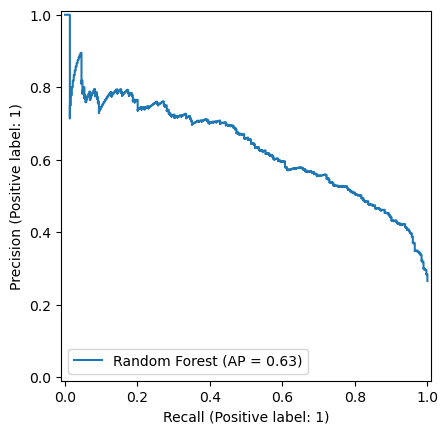

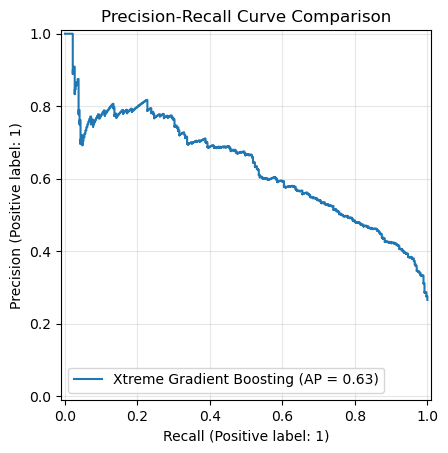

In [41]:
from sklearn.metrics import PrecisionRecallDisplay

plt.figure(figsize=(8,6))

PrecisionRecallDisplay.from_estimator(
    logistic_pipeline,
    X_test,
    y_test,
    name="Logistic Regression"
)

PrecisionRecallDisplay.from_estimator(
    rf_pipeline,
    X_test,
    y_test,
    name="Random Forest"
)

PrecisionRecallDisplay.from_estimator(
    xgb_pipeline,
    X_test,
    y_test,
    name="Xtreme Gradient Boosting"
)

plt.title("Precision-Recall Curve Comparison")

plt.grid(alpha=0.3)

plt.show()

## Performance Comparison

A visual comparison of evaluation metrics provides an intuitive overview of model performance.

The following charts compare the top 3 models using:

- Recall
- F1-score
- ROC-AUC

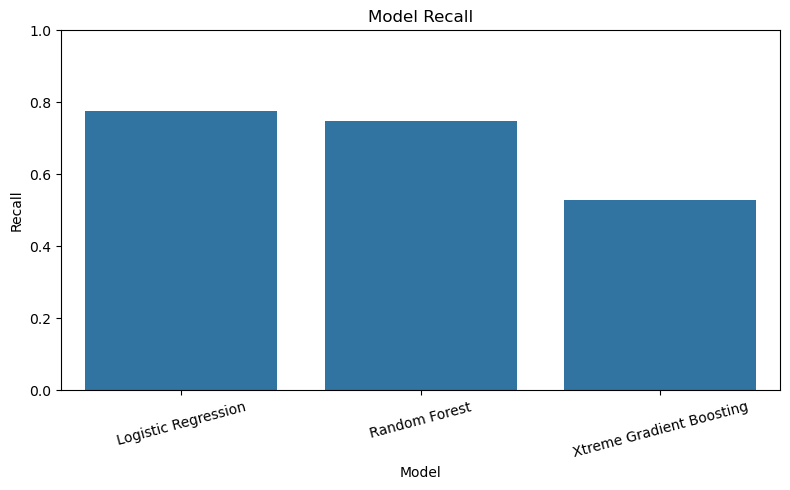

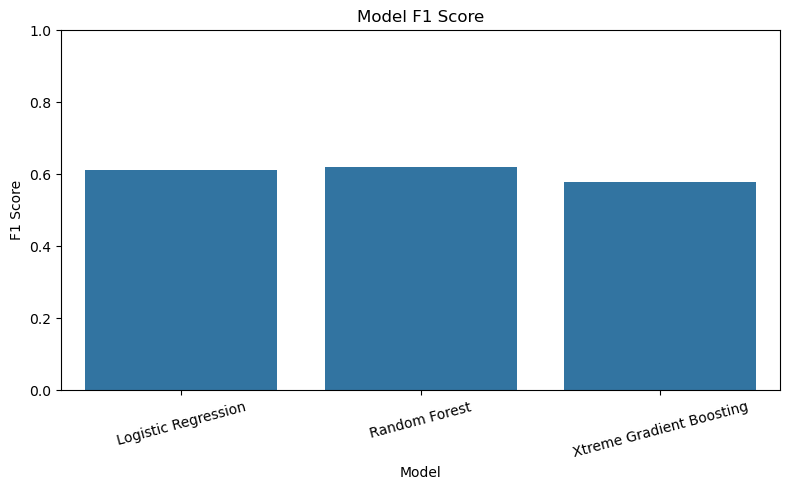

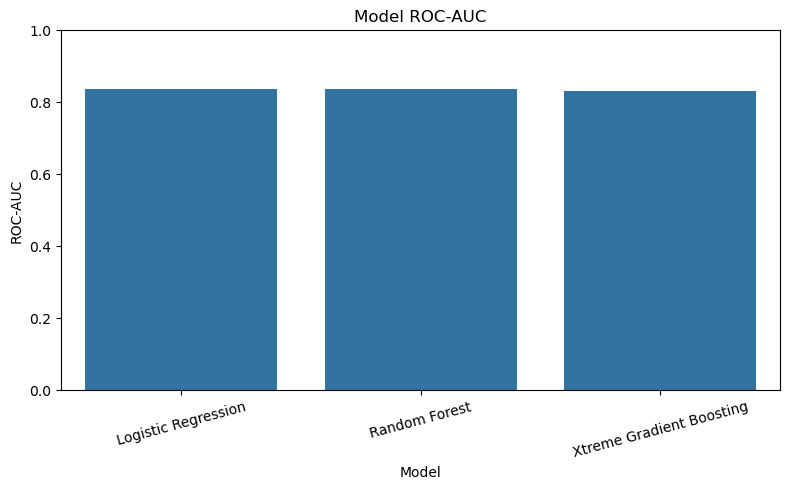

In [42]:
# Recall
plt.figure(figsize=(8,5))

sns.barplot(
    data=top_models,
    x="Model",
    y="Recall"
)

plt.title("Model Recall")

plt.ylim(0,1)

plt.xticks(rotation=15)

plt.tight_layout()

plt.show


# F1 Score
plt.figure(figsize=(8,5))

sns.barplot(
    data=top_models,
    x="Model",
    y="F1 Score"
)

plt.title("Model F1 Score")

plt.ylim(0,1)

plt.xticks(rotation=15)

plt.tight_layout()

plt.show



# ROC-AUC

plt.figure(figsize=(8,5))

sns.barplot(
    data=top_models,
    x="Model",
    y="ROC-AUC"
)

plt.title("Model ROC-AUC")

plt.ylim(0,1)

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

# Baseline Model Summary

The baseline evaluation demonstrates that each algorithm offers different strengths.

While some models achieve higher overall accuracy, others provide better recall or stronger discrimination between churning and non-churning customers.

Since the business objective is to identify customers who are likely to churn, Recall, ROC-AUC, and F1-score are prioritized over Accuracy during model selection.

Rather than selecting a final production model at this stage, the three strongest baseline models will advance to hyperparameter optimization.

This approach reduces the risk of overlooking a model whose performance could improve substantially after tuning.

# Save the Three Baseline Pipelines

In [43]:
# Save Logistic Regression baseline model

joblib.dump(
    logistic_pipeline,
    "../models/logistic_baseline.pkl"
)

# Save Random Forest baseline model

joblib.dump(
    rf_pipeline,
    "../models/random_forest_baseline.pkl"
)

# Save Gradient Boosting baseline model

joblib.dump(
    gb_pipeline,
    "../models/gradient_boosting_baseline.pkl"
)

print("Baseline models saved successfully.")

Baseline models saved successfully.


In [6]:
from pathlib import Path
import os

print("Current working directory:")
print(Path.cwd())

print("\nContents:")
print(os.listdir())

Current working directory:
C:\Users\USER\Documents\Customer-Churn-System\notebooks

Contents:
['.ipynb_checkpoints', '01_data_cleaning.ipynb', '03_Exploratory_Data_Analysis.ipynb', '04_Feature_Engineering.ipynb', '05_Model_Training.ipynb', '06_Model_Optimization.ipynb', '07_Final_Model_Evaluation.ipynb', '08_Business_Insights_and_Model_Interpretation.ipynb', '09 modified.ipynb', '09_Production_Prediction_Pipeline-2.ipynb', '09_Production_Prediction_Pipeline.ipynb']


In [8]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Project root exists:", PROJECT_ROOT.exists())

Project root: C:\Users\USER\Documents\Customer-Churn-System
Project root exists: True


In [10]:
from src.prediction_pipeline import (
    load_production_artifacts,
    run_prediction_pipeline
)

print("✓ Production prediction module imported successfully.")

✓ Production prediction module imported successfully.
